<a href="https://colab.research.google.com/github/23H71A5428/AI-SMART-HEART-DISEASE-PREDICTION-USING-ML/blob/main/MINIPROJECT28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

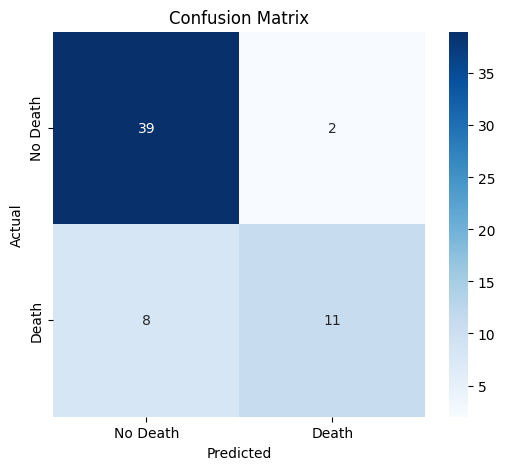

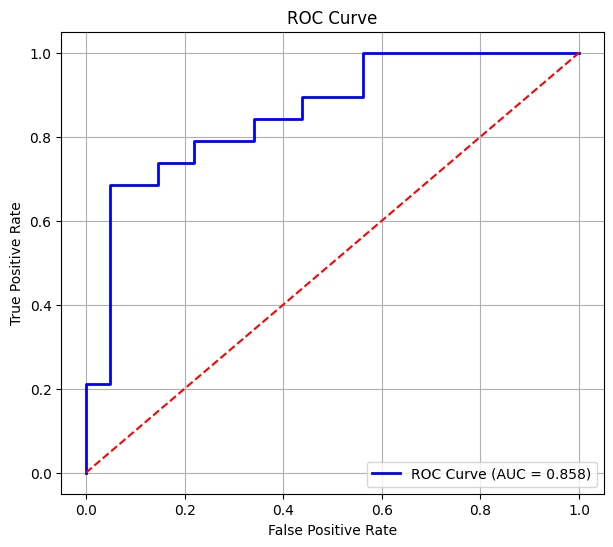

ROC-AUC Score: 0.858


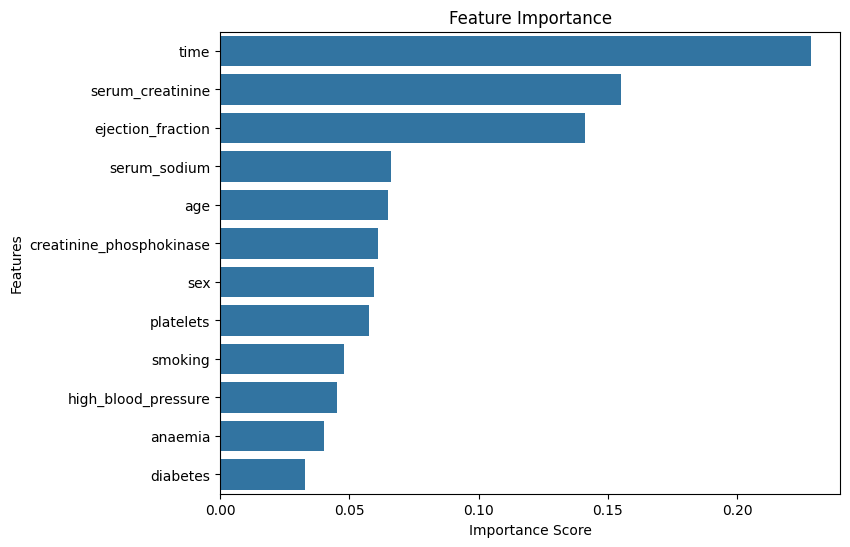

In [1]:
# Install XGBoost (Google Colab)
!pip install -q xgboost

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from xgboost import XGBClassifier

# Load Dataset
df = pd.read_csv('/content/heart_failure_clinical_records_dataset.csv')

# Display Dataset
print(df.head())

# Features and Target
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Build XGBoost Model
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Train Model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy = {:.2f}%".format(accuracy*100))

# Classification Report
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Death','Death'],
    yticklabels=['No Death','Death']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='blue', linewidth=2,
         label='ROC Curve (AUC = {:.3f})'.format(auc))

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

print("ROC-AUC Score:", round(auc,3))

# Feature Importance
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':importance
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()